In [1]:
import torch
import wandb
import pandas as pd
from transformers import Trainer, Seq2SeqTrainer, Seq2SeqTrainingArguments

from Levenshtein import distance

import re
import os
from datetime import datetime

os.chdir("../scripts")

from eval import *
from data_processing import poquad, processing
from t5.load_t5 import *

In [2]:
train_df, valid_df = poquad.load_poquad_manually_downloaded("../data/poquad-manually-processed")

In [3]:
train_input = poquad.dataset_into_str_input(train_df)
valid_input = poquad.dataset_into_str_input(valid_df)

In [4]:
valid_input.index += 1

In [5]:
valid_input["is_impossible"] = valid_input["target_text"].str.contains(r"\[BRAK\_ODPOWIEDZI\]")

In [6]:
models_to_evaluate = [
    ("plt5-original-small", "plt5-original-small"),
    ("plt5-original-base", "plt5-original-base"),
    ("../models/plt5-small-2epochs", "plt5-small-2epochs"),
    ("../scripts/results/checkpoint-22648", "plt5-small-2epochsV2"),
    ("../scripts/results/checkpoint-45296", "plt5-small-4epochs"),
    ("../scripts/results/checkpoint-67944", "plt5-small-6epochs"),
    ("../models/plt5-small-8epochs", "plt5-small-8epochs"),
    ("../models/plt5-large-2epochs", "plt5-large-2epochs"),
    # ("../scripts/results/checkpoint-90692", "plt5-small-8epochs")
 ]

In [7]:
score = []

for model_to_evaluate in models_to_evaluate:
    model_path, model_name = model_to_evaluate

    
    gen_texts = pd.read_json(f"../outputs/{model_name}_eval_0.json", orient="index")

    eval_df = pd.merge(valid_input, gen_texts, left_index=True, right_index=True)

    eval_df = eval_df.rename(columns={0: "gen_text"})

    possible_answers_df = eval_df[~eval_df["is_impossible"]].copy()

    possible_answers_df["target_text"] = possible_answers_df["target_text"].apply(rm_answer_prefix)

    possible_answers_df["gen_text"] = possible_answers_df["gen_text"].apply(rm_answer_prefix)

    lev_result = possible_answers_df[['target_text', 'gen_text']].apply(lambda x: normalized_levenshtein(x.iloc[0], x.iloc[1]), axis=1).mean()

    print(f"Normalized Levenshtein distance for {model_name}:", lev_result)
    
    if "original" not in model_name:    
        f1_result = bin_f1_score(eval_df)

        print(f"Bin F1 score for {model_name}:", f1_result) # It's Bad

    else:
        print(f"{model_name} is original hence it does not know [BRAK_ODPOWIEDZI] token. Skipping F1 score calculation.")
    
    score.append((model_name, lev_result, f1_result if "original" not in model_name else None))


    print("\n")

Normalized Levenshtein distance for plt5-original-small: 0.6374194604863722
plt5-original-small is original hence it does not know [BRAK_ODPOWIEDZI] token. Skipping F1 score calculation.


Normalized Levenshtein distance for plt5-original-base: 0.6264943424560104
plt5-original-base is original hence it does not know [BRAK_ODPOWIEDZI] token. Skipping F1 score calculation.


Normalized Levenshtein distance for plt5-small-2epochs: 0.35094735909191704
Bin F1 score for plt5-small-2epochs: 0.26452064380685797


Normalized Levenshtein distance for plt5-small-2epochsV2: 0.3709441830044724
Bin F1 score for plt5-small-2epochsV2: 0.3169786959328599


Normalized Levenshtein distance for plt5-small-4epochs: 0.3828081996983745
Bin F1 score for plt5-small-4epochs: 0.33230596805827967


Normalized Levenshtein distance for plt5-small-6epochs: 0.3514439698225006
Bin F1 score for plt5-small-6epochs: 0.3392913138915021


Normalized Levenshtein distance for plt5-small-8epochs: 0.3278126758782814
Bin F1 sco

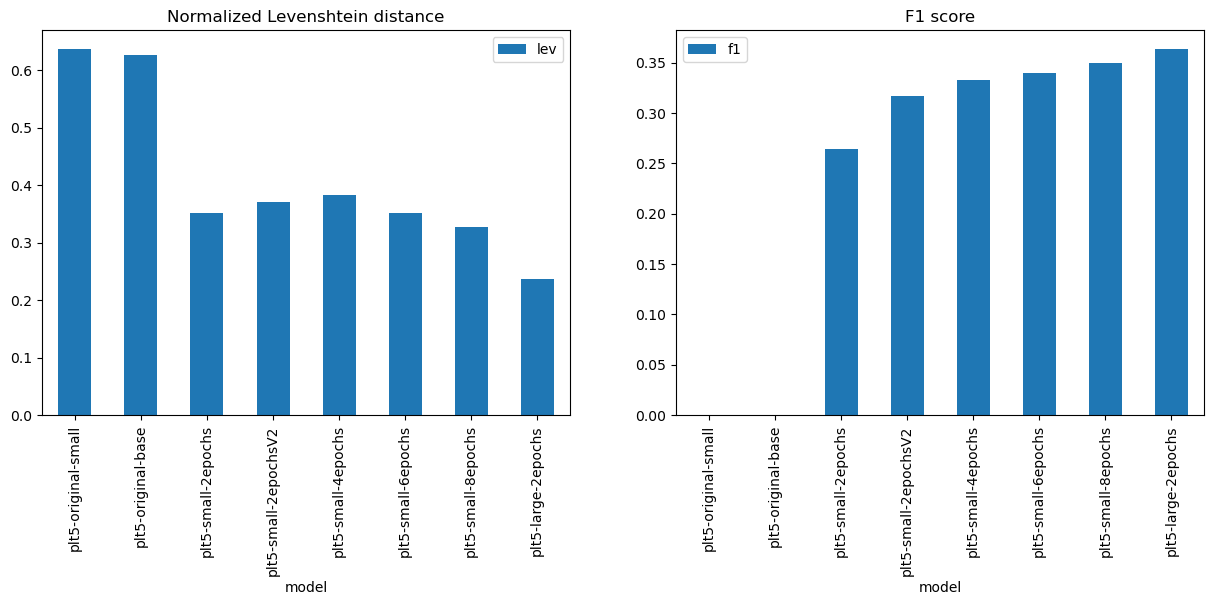

In [8]:
import matplotlib.pyplot as plt

# Create 2 plots next to each other one for Levenshtein distance and one for F1 score

lev_df = pd.DataFrame(score, columns=["model", "lev", "f1"])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

lev_df.plot(kind="bar", x="model", y="lev", ax=ax[0], title="Normalized Levenshtein distance")

lev_df.plot(kind="bar", x="model", y="f1", ax=ax[1], title="F1 score")

plt.show()

### Model improves with more epochs. All models achieve bad F1 Score.